# Protein folding MSM: villin headpiece

**You will learn:** how to take a set of unbiased MD trajectories of a small protein and build a Markov-state model that gives you the folded / unfolded macrostates, the folding timescale, and the folding rate.

**Prerequisites:**
- HTMD installed.
- `wget` available on `$PATH` (or substitute your favourite downloader).
- Patience for a one-time ~1 GB dataset download.

## The system

The villin headpiece is a 35-residue protein with a single hydrophobic core - one of the smallest naturally-occurring autonomously folding domains. We use a set of unbiased explicit-solvent trajectories run at 360 K (above the melting point, so both folded and unfolded states are populated). Total aggregate ≈ 107 µs across 2137 short trajectories.

## The flow

The MSM pipeline you'll follow:

1. **Download + index** the filtered trajectories with {py:func}`~htmd.simlist.simlist`.
2. **Project** the geometry onto a low-dimensional distance space with {py:class}`~moleculekit.projections.metricdistance.MetricSelfDistance`.
3. **Reduce dimensions** with TICA - find the slow collective coordinates.
4. **Cluster** the TICA space into ~1000 microstates.
5. **Build** a Markov model: choose a lag time from the implied-timescales plot, then lump microstates into macrostates with PCCA.
6. **Read kinetics**: equilibrium populations, free-energy surface, mean first-passage times.

## Setup

In [1]:
import os
from glob import glob
from pathlib import Path
from htmd.ui import (
    simlist, simmerge,
    Metric, MetricSelfDistance,
    TICA, Model, Kinetics,
)
from sklearn.cluster import MiniBatchKMeans

2026-06-02 18:43:57,627 - rdkit - INFO - Enabling RDKit 2026.03.2 jupyter extensions



Please cite HTMD: Doerr et al.(2016)JCTC,12,1845. https://dx.doi.org/10.1021/acs.jctc.6b00049
HTMD Documentation at: https://software.acellera.com/htmd/

You are on the latest HTMD version (2.8.5.dev17+gf26491d44.d20260602).



## Step 1 - Build a simulation list

The filtered trajectories (already stripped of waters and ions, aligned for analysis) ship as a zip on Figshare ([HTMD tutorial data, DOI 10.6084/m9.figshare.32541291](https://doi.org/10.6084/m9.figshare.32541291)) - download [protein_folding_datasets.zip](https://ndownloader.figshare.com/files/65180772) and extract it once. ~2.5 GB. The tutorial reads the absolute path from the `HTMD_TUTORIAL_DATASETS` environment variable so the same notebook works regardless of where you extracted to.

The dataset is organised as several "epochs" (independent adaptive-sampling rounds). {py:func}`~htmd.simlist.simlist` builds one list per epoch — duplicate folder basenames within a single call would raise — and {py:func}`~htmd.simlist.simmerge` stitches the per-epoch lists into one combined list, renumbering the `simid` indices to be sequential across the merged whole:

In [2]:
DATASETS = Path(os.environ["HTMD_TUTORIAL_DATASETS"]) / "protein_folding_datasets"
topology = str(DATASETS / "1" / "filtered")  # any epoch works - all share the same topology
sims = []
for epoch in sorted(DATASETS.glob("*/")):
    trajs = glob(os.path.join(epoch, "filtered", "*", ""))
    sims = simmerge(sims, simlist(trajs, topology))
len(sims)

2137

A {py:class}`~htmd.simlist.Sim` is the unit of analysis: trajectory frames + the matching topology / structure file (any moleculekit-supported topology format works — PDB, PSF, prmtop, ...).

## Step 2 - Project geometry to Cα distances

Folding is encoded in the network of Cα-Cα contacts: in the unfolded state the helices are apart, in the folded state they pack against each other. {py:class}`~moleculekit.projections.metricdistance.MetricSelfDistance` computes the upper-triangular distance matrix between every Cα pair, frame by frame. `metric="contacts"` thresholds those distances into 0/1 contacts (1 if below the `threshold`, 0 otherwise - default `threshold=8` Å). Contact features are cheaper and more robust than raw distances for MSMs.

In [3]:
metr = Metric(sims)
metr.set(MetricSelfDistance("protein and name CA", metric="contacts", periodic="chains"))
data = metr.project()
data.fstep = 0.1  # ns per frame - tells downstream code the time axis

htmd.projections.metric - INFO - Frame step 0.1ns was read from the trajectories. If it looks wrong, redefine it by manually setting the MetricData.fstep property.


`data` is a {py:class}`~htmd.metricdata.MetricData` object: per-trajectory projected coordinates plus the metric metadata.

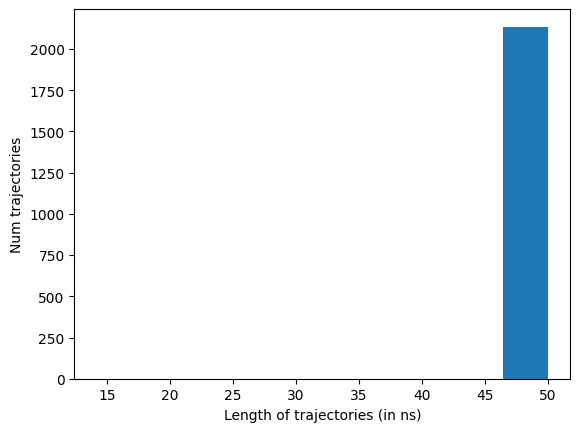

In [4]:
data.plotTrajSizes()

Drop any trajectories whose length isn't the **statistical mode** (the most common frame count). By default `dropTraj()` removes anything off that mode — both crashed (too short) and over-run (too long) — so the rest of the pipeline sees a uniform-length set:

In [5]:
data.dropTraj()

htmd.metricdata - INFO - Dropped 7 trajectories from 2137 resulting in 2130


array([ 168,  472,  709, 1507, 1601, 2100, 2111])

## Step 3 - TICA: find the slow coordinates

TICA (Time-lagged Independent Component Analysis) re-projects the high-dimensional contact space onto the directions of slowest decorrelation. For an MSM, those slow directions are exactly what you want to discretise.

In [6]:
tica = TICA(data, 2, units="ns")        # lag time for the TICA fit
dataTica = tica.project(3)              # keep the 3 slowest TIC coordinates

The lag time you pick here (2 ns) should be a few times the fastest non-trivial relaxation; for villin folding 2 ns is plenty.

## Step 4 - Cluster the TICA space

Discretise the continuous TICA space into ~1000 microstates with mini-batch k-means. Bootstrap the data first (sample 80% of trajs) - re-running with different bootstrap draws gives you deviations / error bars on the timescales and is the standard check that the model is sample-stable:

In [7]:
dataBoot = dataTica.bootstrap(0.8)
dataBoot.cluster(MiniBatchKMeans(n_clusters=1000))

## Step 5 - Build the MSM

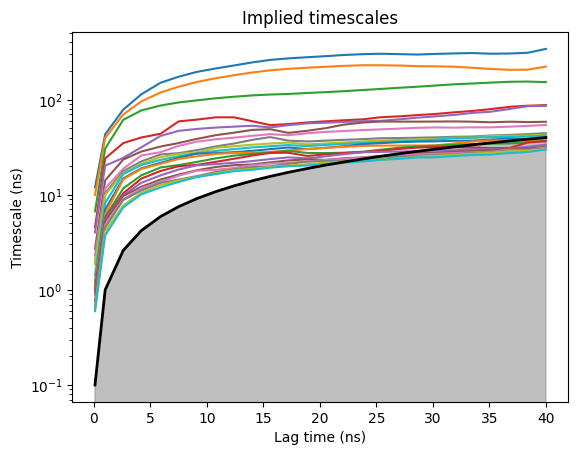

In [8]:
model = Model(dataBoot)
model.plotTimescales(maxlag=40, units="ns")

The implied-timescales (ITS) plot tells you when the model becomes Markovian: pick the **shortest** lag time at which the top timescales have plateaued. For villin folding that's ~25 ns - the slow folding timescale is clearly separated from the bulk continuum.

In [9]:
model.markovModel(25, 4, units="ns")

htmd.model - INFO - 100.0% of the data was used


htmd.model - INFO - Number of trajectories that visited each macrostate:


htmd.model - INFO - [ 116  479   74 1655]


`25` is the MSM lag time in ns; `4` is the number of macrostates PCCA lumps the microstates into. We pick 4 because the ITS plot shows the top 3 timescales clearly separated from the rest of the spectrum - 3 slow processes partition the microstate space into 3 + 1 = 4 metastable basins. The result captures the folded basin + a couple of unfolded sub-states + the transition region.

## Step 6 - Equilibrium populations and FES

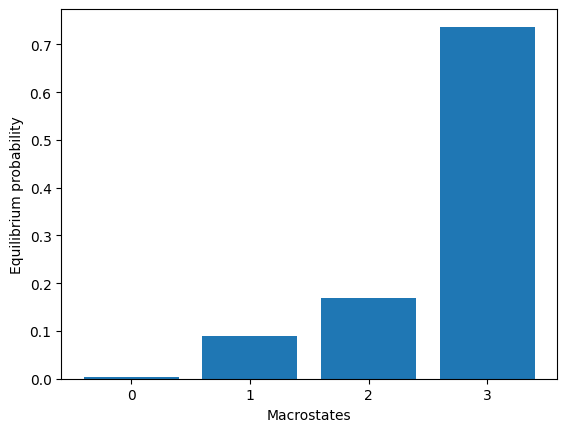

array([0.00353847, 0.09011645, 0.16917454, 0.73717054])

In [10]:
model.eqDistribution()

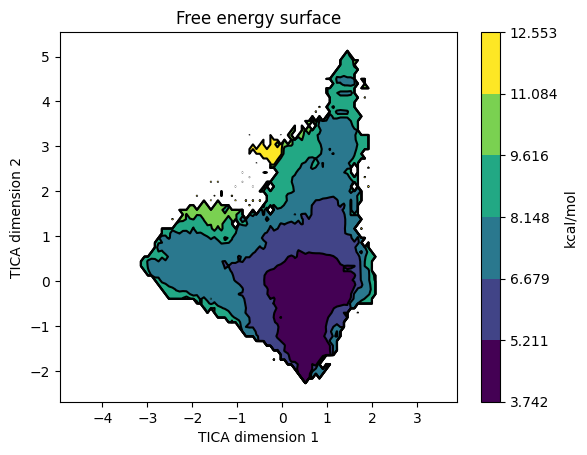

In [11]:
model.plotFES(0, 1, temperature=360)

The FES on TIC1 / TIC2 shows the macrostate basins. Overlay the state assignments:

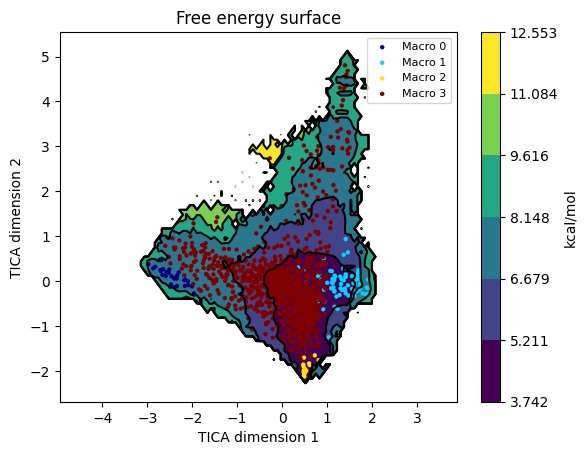

In [12]:
model.plotFES(0, 1, temperature=360, states=True)

To eyeball the macrostates as structures, run `model.viewStates(protein=True)` from an interactive session - it launches VMD with one representative frame per macrostate. (Omitted here because it needs a display.)

## Step 7 - Kinetics

In [13]:
kin = Kinetics(model, temperature=360)
r = kin.getRates()
print(r)

htmd.kinetics - INFO - Detecting source state...


htmd.kinetics - INFO - Guessing the source state as the state with minimum contacts.


htmd.kinetics - INFO - Source macro = 3


htmd.kinetics - INFO - Detecting sink state...


htmd.kinetics - INFO - Sink macro = 2


htmd.kinetics - INFO - Calculating rates between source: [np.int64(3)] and sink: [np.int64(2)] states.


mfpton = 2.09E+03 (ns)
mfptoff = 2.35E+02 (ns)
kon = 4.79E+05 (1/M 1/s)
koff = 4.25E+06 (1/s)
koff/kon = 8.87E+00 (M)
kdeq = 4.36E+00 (M)
g0eq = 1.05 (kcal/M)



`Kinetics` reads the macrostate model and computes mean-first-passage times and rates. {py:meth}`~htmd.kinetics.Kinetics.getRates` returns a single `Rates` object for one auto-detected source → sink pair (folded → unfolded by default). To inspect *all* pairs, pass `source=` / `sink=` explicitly per call, or use `kin.plotRates()` (below) which iterates internally.

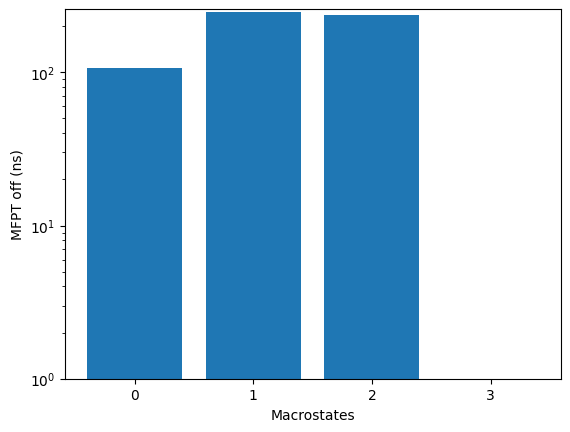

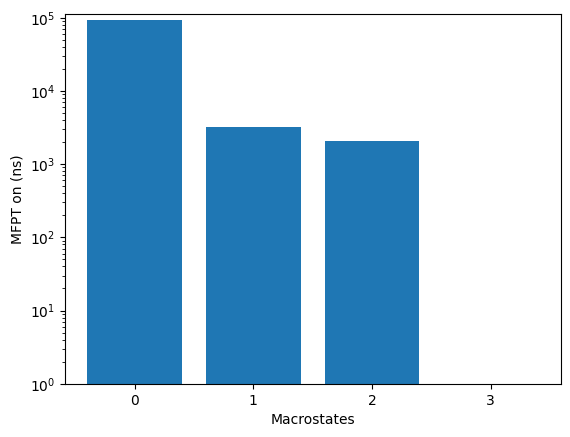

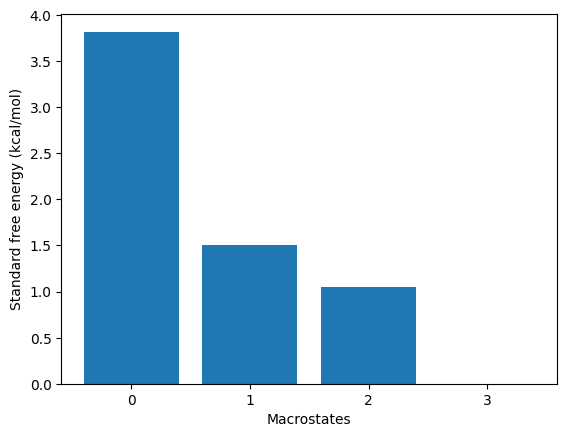

In [14]:
kin.plotRates()

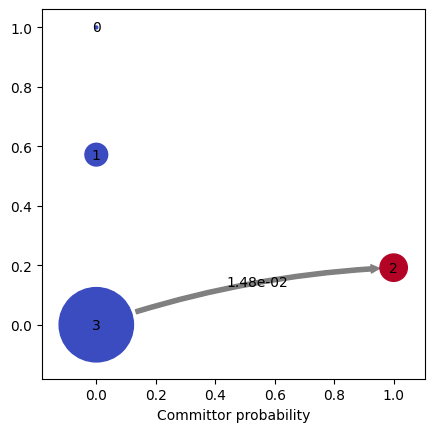

Path flux		%path	%of total	path
0.014825165238110399	100.0%	100.0%		[3 2]


In [15]:
kin.plotFluxPathways()

Flux pathways visualise the dominant transition routes in TPT (transition-path theory) form - which intermediates the protein actually visits on its way from unfolded to folded.

## Parameters that matter

| Knob | Effect |
| --- | --- |
| `MetricSelfDistance(... metric="contacts")` | Contact features are coarser but more robust than raw distances - the binary thresholding makes clusters insensitive to small Cα-Cα fluctuations within a folded basin. |
| `TICA(data, 2, units="ns")` lag | Set a few times the fastest non-trivial relaxation. Too small → noise; too large → loses fast slow modes. |
| `tica.project(3)` | Number of TIC coordinates kept. 3-5 is typical; check the eigenvalue spectrum to decide. |
| `MiniBatchKMeans(n_clusters=1000)` | More clusters = finer microstate resolution but slower. 500-2000 is the usual range. |
| `model.markovModel(25, 4, units="ns")` lag | Read off the ITS plot - shortest lag at which slow timescales plateau. |
| `model.markovModel(..., macronum=4)` | PCCA macrostates. Look at the timescale gaps in the ITS plot to pick the number. |

## Gotchas

- **ITS plateau, not minimum.** Pick the lag where slow timescales *first level off*, not where they're highest. Too-long lags throw away kinetic resolution for no gain.
- **`bootstrap(0.8)`** lets you get deviations / error bars and see whether the model is sample-stable. Re-run with several bootstrap draws and compare; if different bootstraps give wildly different ITS / states, your dataset is undersampled.
- **Macrostate count is a judgement call.** Look at the timescale gap pattern - if you see a clear gap after k slow timescales, take k+1 macrostates.

## See also

- {doc}`MSM workflow explanation <../../explanation/msm-workflow>` - the conceptual pipeline behind these calls.
- {doc}`Ligand binding MSM <trypsin-benzamidine-binding>` - the same pipeline for a binding system (uses `MetricDistance` between protein and ligand instead of `MetricSelfDistance` on the protein).
- {doc}`Adaptive sampling <../adaptive/index>` - how to *generate* the trajectory set that feeds this analysis.